In [1]:
import pandas as pd
import json

import random
import geopandas as gpd
import numpy as np
import os

enc = 'utf-8'
random.seed(0)
np.random.seed(0)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
folder_path = 'shapefiles/EUROPE_LAU_2021_4326'   

europe_lau = gpd.read_file(f"{folder_path}/LAU_RG_01M_2021_4326.shp",  encoding=enc)

In [3]:
europe_lau

,GISCO_ID,CNTR_CODE,LAU_ID,LAU_NAME,POP_2021,POP_DENS_2,AREA_KM2,YEAR,FID,geometry
0,CZ_578622,CZ,578622,Příluka,169,44.874443,3.766064,2021,CZ_578622,"POLYGON ((16.17291 49.87185, 16.17857 49.86316..."
1,CZ_578631,CZ,578631,Pustá Kamenice,317,20.778047,15.256487,2021,CZ_578631,"POLYGON ((16.12256 49.74090, 16.11414 49.74097..."
2,AT_40708,AT,40708,Gschwandt,2880,172.195052,16.725219,2021,AT_40708,"POLYGON ((13.85372 47.90813, 13.83663 47.91080..."
3,CZ_578649,CZ,578649,Pustá Rybná,158,11.300622,13.981531,2021,CZ_578649,"POLYGON ((16.14493 49.68658, 16.13991 49.69125..."
4,CZ_578657,CZ,578657,Radiměř,1158,40.452951,28.625848,2021,CZ_578657,"POLYGON ((16.44808 49.70979, 16.46316 49.70417..."
...,...,...,...,...,...,...,...,...,...,...
98183,AT_40444,AT,40444,Treubach,737,56.461344,13.053178,2021,AT_40444,"POLYGON ((13.22548 48.17767, 13.19886 48.17640..."
98184,CZ_572772,CZ,572772,Bystřice,343,49.157090,6.977630,2021,CZ_572772,"POLYGON ((15.26383 50.38634, 15.25207 50.38729..."
98185,CZ_572781,CZ,572781,Cerekvice nad Bystřicí,783,94.720381,8.266436,2021,CZ_572781,"POLYGON ((15.70338 50.32198, 15.70148 50.32938..."
98186,CZ_572799,CZ,572799,Časy,239,92.734955,2.577237,2021,CZ_572799,"POLYGON ((15.90580 50.05973, 15.90208 50.05564..."


In [4]:
with open('country_codes.json') as json_file:
    country_codes = json.load(json_file)

In [5]:
europe_lau['CNTR_NAME'] = europe_lau['CNTR_CODE'].map(country_codes) 

In [6]:
europe_lau['GISCO_ID'].equals(europe_lau['FID'])

True

In [7]:
europe_lau.drop(columns=['GISCO_ID'], inplace = True)

In [8]:
print(f'europe_lau CRS: {europe_lau.crs}')

europe_lau CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [9]:
europe_lau = europe_lau.to_crs(epsg=4326)

In [10]:
print(f'europe_lau CRS: {europe_lau.crs}')

europe_lau CRS: epsg:4326


<AxesSubplot:>

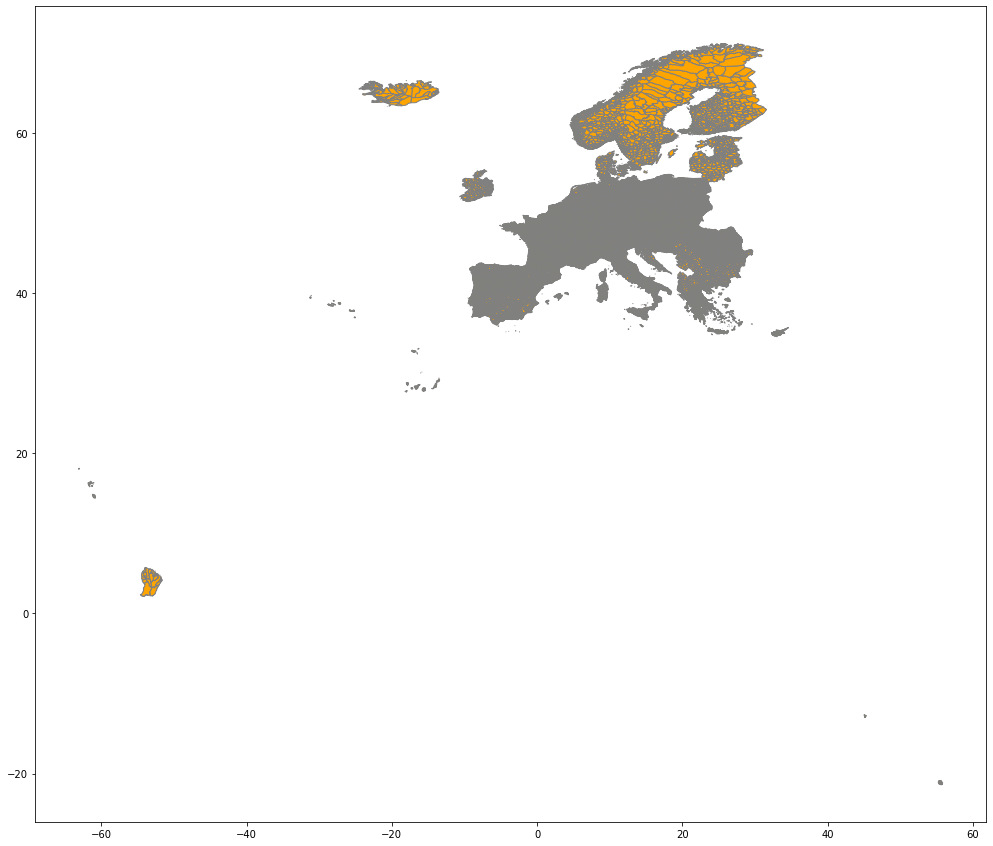

In [12]:
europe_lau.plot(facecolor="none", edgecolor='grey', figsize=(20, 15), color='orange')

In [13]:
lau_el = europe_lau.loc[europe_lau['CNTR_CODE'] == 'EL'].copy()

In [15]:
lau_el.reset_index(drop = True, inplace = True)

In [16]:
lau_el

,CNTR_CODE,LAU_ID,LAU_NAME,POP_2021,POP_DENS_2,AREA_KM2,YEAR,FID,geometry,CNTR_NAME
0,EL,07030301,Κοινότητα Νέας Απολλωνίας,1922,26.928293,71.374742,2021,EL_07030301,"POLYGON ((23.40513 40.67990, 23.46122 40.67637...",Greece
1,EL,07030302,Κοινότητα Μελισσουργού,417,18.309180,22.775460,2021,EL_07030302,"POLYGON ((23.50857 40.56822, 23.49778 40.57158...",Greece
2,EL,07030303,Κοινότητα Νικομηδινού,519,43.149097,12.028062,2021,EL_07030303,"POLYGON ((23.28643 40.62468, 23.28383 40.62394...",Greece
3,EL,07030304,Κοινότητα Περιστερώνας,442,8.652268,51.084873,2021,EL_07030304,"POLYGON ((23.30085 40.63293, 23.31534 40.63474...",Greece
4,EL,07030305,Κοινότητα Στίβου,576,50.867526,11.323531,2021,EL_07030305,"POLYGON ((23.31531 40.67441, 23.31410 40.66175...",Greece
...,...,...,...,...,...,...,...,...,...,...
6132,EL,05020301,Κοινότητα Λεκάνης,485,7.095832,68.349979,2021,EL_05020301,"POLYGON ((24.49416 41.20145, 24.51860 41.19500...",Greece
6133,EL,01010103,Κοινότητα Γρατίνης,365,26.320330,13.867607,2021,EL_01010103,"POLYGON ((25.54000 41.11110, 25.53224 41.11687...",Greece
6134,EL,06020102,Κοινότητα Διομηδείας,4421,148.145502,29.842283,2021,EL_06020102,"POLYGON ((24.93392 41.04362, 24.91963 41.05359...",Greece
6135,EL,01040109,Κοινότητα Νέας Σάντας,188,2.873422,65.427213,2021,EL_01040109,"POLYGON ((25.73638 41.09225, 25.72515 41.09365...",Greece


<AxesSubplot:>

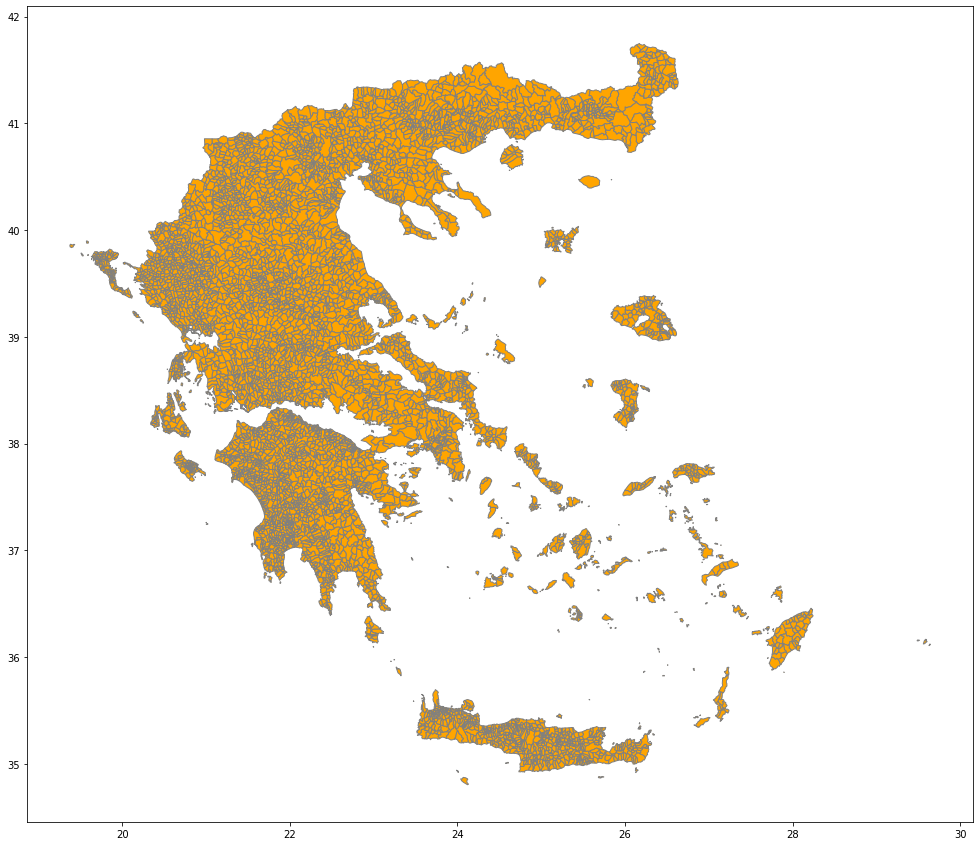

In [17]:
lau_el.plot(facecolor="none", edgecolor='grey', figsize=(20, 15), color='orange')

In [20]:
laus = lau_el.LAU_NAME.tolist()